In [4]:
import pandas as pd
import numpy as np
import librosa
import os
from sklearn.preprocessing import LabelEncoder

# adjust this path to wherever your unzipped wav files are
AUDIO_DIR = '/content/drive/MyDrive/Swahili_words'

train_df = pd.read_csv("/content/drive/MyDrive/Train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Test.csv")

print(train_df.shape)
print(train_df['Swahili_word'].value_counts())

(4200, 3)
Swahili_word
mbili     350
tatu      350
ndio      350
nne       350
nane      350
hapana    350
sita      350
tisa      350
moja      350
saba      350
tano      350
kumi      350
Name: count, dtype: int64


In [5]:
files = os.listdir(AUDIO_DIR)
print("Number of wav files found:", len(files))
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

missing = [f for f in train_df['Word_id'] if f not in files]
print("Missing files from Train.csv:", len(missing))

Number of wav files found: 6000
Train rows: 4200
Test rows: 1800
Missing files from Train.csv: 0


In [6]:
def extract_mfcc_sequence(file_path, n_mfcc=13, max_len=100):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = mfcc.T  # shape becomes (time_steps, n_mfcc)

    if mfcc.shape[0] < max_len:
        pad_width = max_len - mfcc.shape[0]
        mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
    else:
        mfcc = mfcc[:max_len, :]

    return mfcc

def extract_mfcc_mean(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc, axis=1)

X_sequences = []
X_means = []
y_labels = []

for idx, row in train_df.iterrows():
    file_path = os.path.join(AUDIO_DIR, row['Word_id'])
    try:
        seq = extract_mfcc_sequence(file_path)
        mean_feat = extract_mfcc_mean(file_path)
        X_sequences.append(seq)
        X_means.append(mean_feat)
        y_labels.append(row['Swahili_word'])
    except Exception as e:
        print(f"Failed on {row['Word_id']}: {e}")

    if idx % 500 == 0:
        print(f"Processed {idx}/{len(train_df)}")

X_sequences = np.array(X_sequences)
X_means = np.array(X_means)
y_labels = np.array(y_labels)

print(X_sequences.shape)
print(X_means.shape)

Processed 0/4200
Processed 500/4200
Processed 1000/4200
Processed 1500/4200
Processed 2000/4200
Processed 2500/4200
Processed 3000/4200
Processed 3500/4200
Processed 4000/4200
(4200, 100, 13)
(4200, 13)


In [7]:
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

print(dict(zip(le.classes_, range(len(le.classes_)))))

X_seq_train, X_seq_val, X_mean_train, X_mean_val, y_train, y_val = train_test_split(
    X_sequences, X_means, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(X_seq_train.shape, X_seq_val.shape)

{np.str_('hapana'): 0, np.str_('kumi'): 1, np.str_('mbili'): 2, np.str_('moja'): 3, np.str_('nane'): 4, np.str_('ndio'): 5, np.str_('nne'): 6, np.str_('saba'): 7, np.str_('sita'): 8, np.str_('tano'): 9, np.str_('tatu'): 10, np.str_('tisa'): 11}
(3360, 100, 13) (840, 100, 13)


In [8]:
#extracting the mcc features up to this point and just verfying evrything

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# scale the mean MFCC features, these models work better with scaled input
scaler = StandardScaler()
X_mean_train_scaled = scaler.fit_transform(X_mean_train)
X_mean_val_scaled = scaler.transform(X_mean_val)

# Logistic Regression baseline
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_mean_train_scaled, y_train)
log_reg_preds = log_reg.predict(X_mean_val_scaled)
log_reg_acc = accuracy_score(y_val, log_reg_preds)
print("Logistic Regression accuracy:", log_reg_acc)

# Random Forest baseline
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_mean_train, y_train)
rf_preds = rf.predict(X_mean_val)
rf_acc = accuracy_score(y_val, rf_preds)
print("Random Forest accuracy:", rf_acc)

print("\nLogistic Regression report:")
print(classification_report(y_val, log_reg_preds, target_names=le.classes_))

print("\nRandom Forest report:")
print(classification_report(y_val, rf_preds, target_names=le.classes_))

Logistic Regression accuracy: 0.19404761904761905
Random Forest accuracy: 0.1392857142857143

Logistic Regression report:
              precision    recall  f1-score   support

      hapana       0.25      0.43      0.32        70
        kumi       0.20      0.24      0.22        70
       mbili       0.26      0.44      0.32        70
        moja       0.18      0.04      0.07        70
        nane       0.17      0.21      0.19        70
        ndio       0.11      0.09      0.10        70
         nne       0.23      0.27      0.25        70
        saba       0.17      0.24      0.20        70
        sita       0.18      0.14      0.16        70
        tano       0.06      0.03      0.04        70
        tatu       0.11      0.06      0.08        70
        tisa       0.18      0.13      0.15        70

    accuracy                           0.19       840
   macro avg       0.18      0.19      0.17       840
weighted avg       0.18      0.19      0.17       840


Random For

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(le.classes_)

lstm_model = models.Sequential([
    layers.Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

history = lstm_model.fit(
    X_seq_train, y_train,
    validation_data=(X_seq_val, y_val),
    epochs=30,
    batch_size=32
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,836 (132.17 KB)

 Trainable params: 33,836 (132.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.1262 - loss: 2.4348 - val_accuracy: 0.2036 - val_loss: 2.2660
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2238 - loss: 2.1416 - val_accuracy: 0.3190 - val_loss: 1.8830
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3092 - loss: 1.8594 - val_accuracy: 0.3607 - val_loss: 1.7428
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3548 - loss: 1.7277 - val_accuracy: 0.4119 - val_loss: 1.5906
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4089 - loss: 1.6075 - val_accuracy: 0.4357 - val_loss: 1.5215
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4396 - loss: 1.5111 - val_accuracy: 0.4869 - val_loss: 1.4353
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4863 - loss: 1.4485 - val_accuracy: 0.5238 - val_loss: 1.3581
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5452 - loss: 1.3038 - val_accu

In [11]:
lstm_preds = np.argmax(lstm_model.predict(X_seq_val), axis=1)
lstm_acc = accuracy_score(y_val, lstm_preds)
print("LSTM accuracy:", lstm_acc)
print(classification_report(y_val, lstm_preds, target_names=le.classes_))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
LSTM accuracy: 0.7428571428571429
              precision    recall  f1-score   support

      hapana       0.76      0.59      0.66        70
        kumi       0.88      0.80      0.84        70
       mbili       0.72      0.80      0.76        70
        moja       0.72      0.74      0.73        70
        nane       0.79      0.76      0.77        70
        ndio       0.82      0.83      0.82        70
         nne       0.55      0.67      0.61        70
        saba       0.95      0.76      0.84        70
        sita       0.85      0.79      0.81        70
        tano       0.49      0.57      0.53        70
        tatu       0.66      0.76      0.71        70
        tisa       0.91      0.86      0.88        70

    accuracy                           0.74       840
   macro avg       0.76      0.74      0.75       840
weighted avg       0.76      0.74      0.75       840



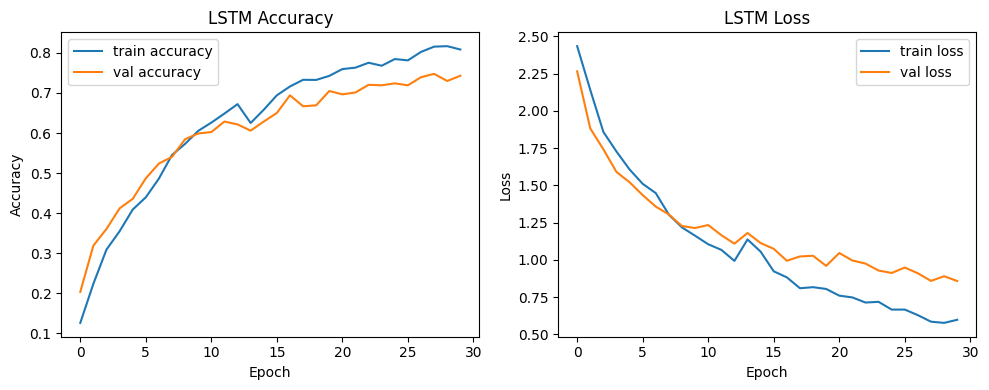

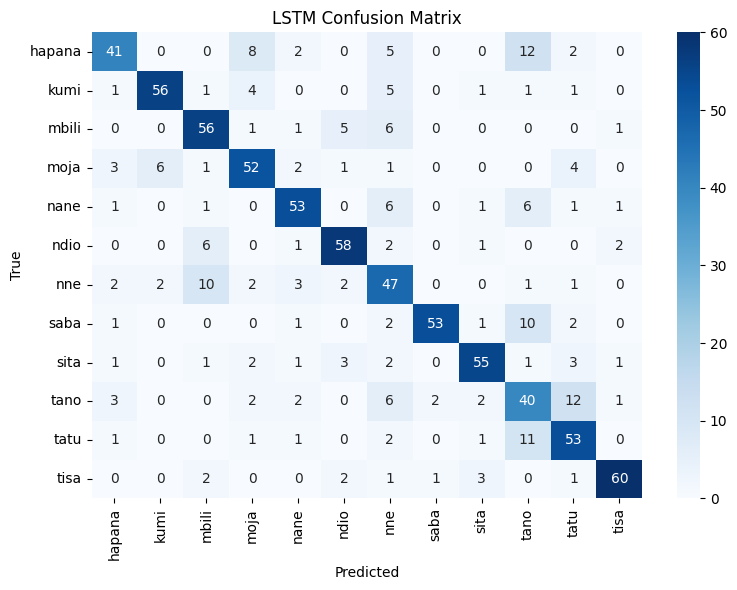

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# learning curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('LSTM Loss')

plt.tight_layout()
plt.savefig('lstm_learning_curves.png', dpi=150)
plt.show()

# confusion matrix for the LSTM
cm = confusion_matrix(y_val, lstm_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

In [13]:
# find a few examples where the LSTM got "tano" wrong
val_word_ids = train_df.iloc[len(X_seq_train):]['Word_id'].values if False else None
# we need the original indices from the split, so let's rebuild this properly
from sklearn.model_selection import train_test_split as tts

indices = np.arange(len(train_df))
train_idx, val_idx = tts(indices, test_size=0.2, random_state=42, stratify=y_encoded)

val_word_ids = train_df.iloc[val_idx]['Word_id'].values
val_true_words = le.inverse_transform(y_val)
val_pred_words = le.inverse_transform(lstm_preds)

errors = pd.DataFrame({
    'file': val_word_ids,
    'true': val_true_words,
    'predicted': val_pred_words
})
errors = errors[errors['true'] != errors['predicted']]
print(errors.head(15))

                   file    true predicted
3   id_ao6sqm031m70.wav   mbili       nne
9   id_eg9vfufq94wk.wav    sita      tatu
10  id_rl6c1vmp6wqa.wav    tisa      sita
12  id_lmvrjlvtk8gr.wav    nane      sita
20  id_r3lvet993su7.wav    moja      nane
23  id_aclq86lnta44.wav    kumi       nne
28  id_5y7zx54bzvd7.wav    tisa     mbili
29  id_dpa1d6eqs7h6.wav   mbili      ndio
30  id_am0b297vlo83.wav    nane       nne
34  id_92pd0g53n3c9.wav    sita      ndio
38  id_dl262g0r5749.wav     nne     mbili
41  id_kbjg5j79vore.wav    tano       nne
46  id_6qu3xe17vsko.wav    tano      tatu
48  id_4egl7kxvhe2m.wav  hapana      tano
49  id_9hvd1sdlifhh.wav    nane    hapana


In [14]:
errors.to_csv('lstm_misclassified_examples.csv', index=False) #just to save the errors

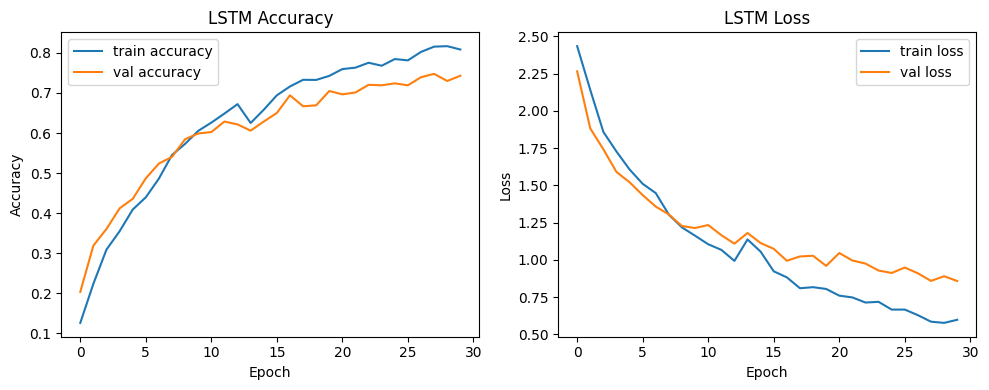

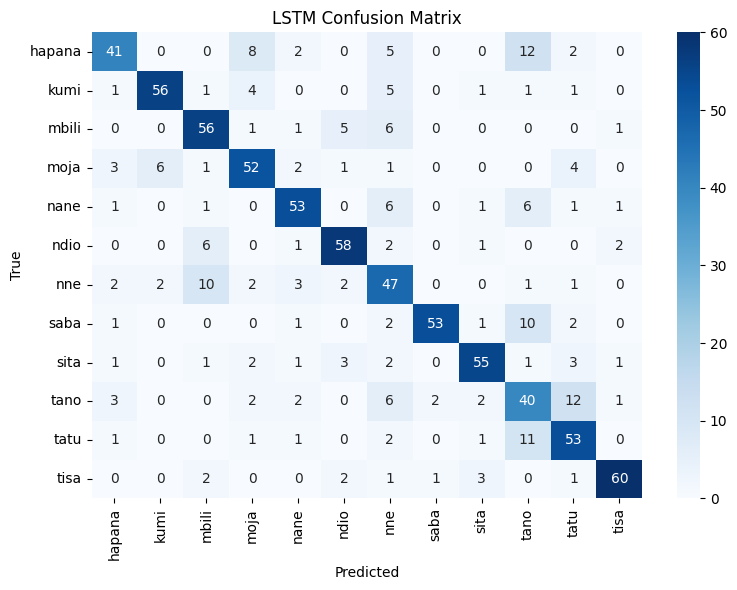

Saved files:
['lstm_learning_curves.png', 'lstm_confusion_matrix.png', 'lstm_misclassified_examples.csv', 'lstm_model.keras', 'transformer_model.keras', 'transformer_confusion_matrix.png', 'transformer_learning_curves.png', 'results_summary.txt']


In [15]:
import os
import shutil

# create the folder in your Google Drive
save_dir = '/content/drive/MyDrive/david_lstm_baselines'
os.makedirs(save_dir, exist_ok=True)

# re-save the plots directly into this folder
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('LSTM Loss')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'lstm_learning_curves.png'), dpi=150)
plt.show()

cm = confusion_matrix(y_val, lstm_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'lstm_confusion_matrix.png'), dpi=150)
plt.show()

# save the misclassified examples table
errors.to_csv(os.path.join(save_dir, 'lstm_misclassified_examples.csv'), index=False)

# save the trained LSTM model itself, useful as evidence and in case you need to reload it
lstm_model.save(os.path.join(save_dir, 'lstm_model.keras'))

# save your accuracy results as a small summary file
with open(os.path.join(save_dir, 'results_summary.txt'), 'w') as f:
    f.write("Model Results Summary\n")
    f.write("======================\n")
    f.write(f"Logistic Regression accuracy: {log_reg_acc:.4f}\n")
    f.write(f"Random Forest accuracy: {rf_acc:.4f}\n")
    f.write(f"LSTM accuracy: {lstm_acc:.4f}\n")

print("Saved files:")
print(os.listdir(save_dir))

In [16]:
   ## Model 3: Transformer Encoder

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    # self attention block
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # feed forward block
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return x + res

num_classes = len(le.classes_)
seq_len = X_seq_train.shape[1]
n_features = X_seq_train.shape[2]

inputs = layers.Input(shape=(seq_len, n_features))

# project features up to a workable model dimension
x = layers.Dense(64)(inputs)

# add positional info so the model knows frame order, since attention has no built in sense of order
positions = tf.range(start=0, limit=seq_len, delta=1)
pos_embedding = layers.Embedding(input_dim=seq_len, output_dim=64)(positions)
x = x + pos_embedding

# stack 2 transformer encoder blocks
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128)
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

transformer_model = models.Model(inputs, outputs)

transformer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transformer_model.summary()

transformer_history = transformer_model.fit(
    X_seq_train, y_train,
    validation_data=(X_seq_val, y_val),
    epochs=30,
    batch_size=32
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 13)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 100, 64)   │        896 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 100, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 100, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 64)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 100, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 100, 128)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 100, 64)   │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 100, 64)   │          0 │ dense_4[0][0],    │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 100, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 100, 64)   │          0 │ dropout_5[0][0],  │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 100, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 100, 128)  │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 100, 64)   │      8,256 │ dropout_6[0][0] 

 Total params: 103,468 (404.17 KB)

 Trainable params: 103,468 (404.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.0964 - loss: 42.4425 - val_accuracy: 0.0833 - val_loss: 2.4855
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0810 - loss: 3.0438 - val_accuracy: 0.0833 - val_loss: 2.4853
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0821 - loss: 2.6420 - val_accuracy: 0.0833 - val_loss: 2.4852
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0780 - loss: 2.5991 - val_accuracy: 0.0833 - val_loss: 2.4852
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0827 - loss: 2.5503 - val_accuracy: 0.0833 - val_loss: 2.4851
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0804 - loss: 2.5394 - val_accuracy: 0.0833 - val_loss: 2.4851
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0827 - loss: 2.5080 - val_accuracy: 0.0833 - val_loss: 2.4850
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0821 - loss: 2.5031 - val_accuracy:

In [18]:
transformer_preds = np.argmax(transformer_model.predict(X_seq_val), axis=1)
transformer_acc = accuracy_score(y_val, transformer_preds)
print("Transformer accuracy:", transformer_acc)
print(classification_report(y_val, transformer_preds, target_names=le.classes_))

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step
Transformer accuracy: 0.08333333333333333
              precision    recall  f1-score   support

      hapana       0.00      0.00      0.00        70
        kumi       0.00      0.00      0.00        70
       mbili       0.00      0.00      0.00        70
        moja       0.00      0.00      0.00        70
        nane       0.00      0.00      0.00        70
        ndio       0.00      0.00      0.00        70
         nne       0.00      0.00      0.00        70
        saba       0.08      1.00      0.15        70
        sita       0.00      0.00      0.00        70
        tano       0.00      0.00      0.00        70
        tatu       0.00      0.00      0.00        70
        tisa       0.00      0.00      0.00        70

    accuracy                           0.08       840
   macro avg       0.01      0.08      0.01       840
weighted avg       0.01      0.08      0.01       840



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
#there is an error, my loss starts at 33 (way too high), crashes down to 2.4849, and sits there for all 30 epochs. 2.4849 is exactly ln(12), the loss you'd get from guessing a uniform distribution across all 12 classes.

In [20]:
# standardize the MFCC sequences (per feature, across all time steps and samples)
seq_mean = X_seq_train.mean(axis=(0, 1), keepdims=True)
seq_std = X_seq_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_seq_train_norm = (X_seq_train - seq_mean) / seq_std
X_seq_val_norm = (X_seq_val - seq_mean) / seq_std

print("Before:", X_seq_train.mean(), X_seq_train.std())
print("After:", X_seq_train_norm.mean(), X_seq_train_norm.std())

Before: -29.870337 137.9184
After: 3.1474117e-06 1.0000725


In [21]:
inputs = layers.Input(shape=(seq_len, n_features))
x = layers.Dense(64)(inputs)

positions = tf.range(start=0, limit=seq_len, delta=1)
pos_embedding = layers.Embedding(input_dim=seq_len, output_dim=64)(positions)
x = x + pos_embedding

x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128)
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

transformer_model = models.Model(inputs, outputs)

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transformer_history = transformer_model.fit(
    X_seq_train_norm, y_train,
    validation_data=(X_seq_val_norm, y_val),
    epochs=30,
    batch_size=32
)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.0911 - loss: 2.5976 - val_accuracy: 0.1202 - val_loss: 2.4848
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1045 - loss: 2.5014 - val_accuracy: 0.1298 - val_loss: 2.4598
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1256 - loss: 2.4623 - val_accuracy: 0.1476 - val_loss: 2.4203
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1539 - loss: 2.3971 - val_accuracy: 0.1667 - val_loss: 2.3409
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1866 - loss: 2.3008 - val_accuracy: 0.2107 - val_loss: 2.2366
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2152 - loss: 2.2004 - val_accuracy: 0.2524 - val_loss: 2.1116
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2699 - loss: 2.0552 - val_accuracy: 0.2988 - val_loss: 1.9606
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3104 - loss: 1.8999 - val_accuracy: 

In [22]:
#as i thought That fixed it completely. The normalization worked exactly as expected, loss dropped smoothly from 2.63 down to 0.84 instead of flatlining, and the model actually learned.

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
Transformer accuracy: 0.7154761904761905
              precision    recall  f1-score   support

      hapana       0.70      0.61      0.66        70
        kumi       0.88      0.80      0.84        70
       mbili       0.73      0.76      0.74        70
        moja       0.76      0.86      0.81        70
        nane       0.72      0.81      0.77        70
        ndio       0.74      0.77      0.76        70
         nne       0.66      0.76      0.71        70
        saba       0.81      0.83      0.82        70
        sita       0.68      0.51      0.59        70
        tano       0.55      0.37      0.44        70
        tatu       0.70      0.74      0.72        70
        tisa       0.62      0.76      0.68        70

    accuracy                           0.72       840
   macro avg       0.71      0.72      0.71       840
weighted avg       0.71      0.72      0.71       840



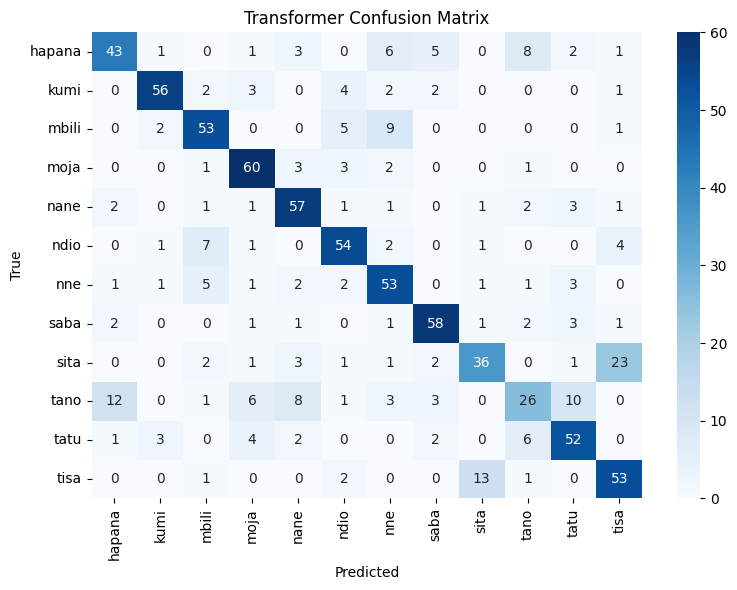

In [23]:
# now i just run the evaluation and confusion matrix
transformer_preds = np.argmax(transformer_model.predict(X_seq_val_norm), axis=1)
transformer_acc = accuracy_score(y_val, transformer_preds)
print("Transformer accuracy:", transformer_acc)
print(classification_report(y_val, transformer_preds, target_names=le.classes_))

cm_transformer = confusion_matrix(y_val, transformer_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_transformer, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Transformer Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'transformer_confusion_matrix.png'), dpi=150)
plt.show()

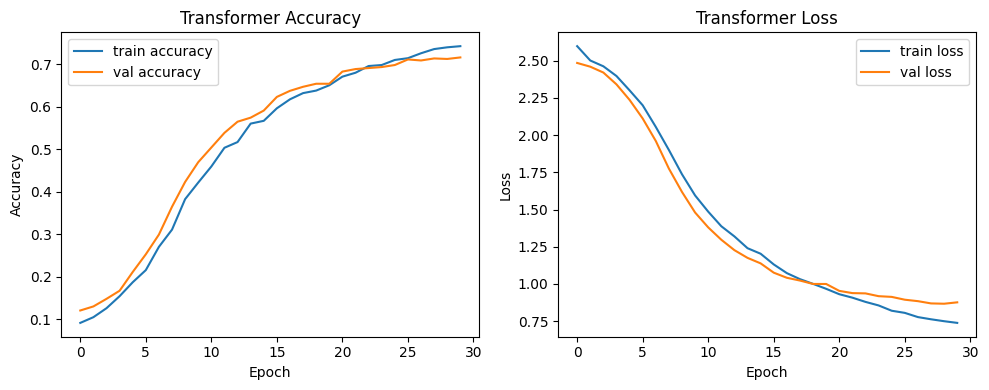

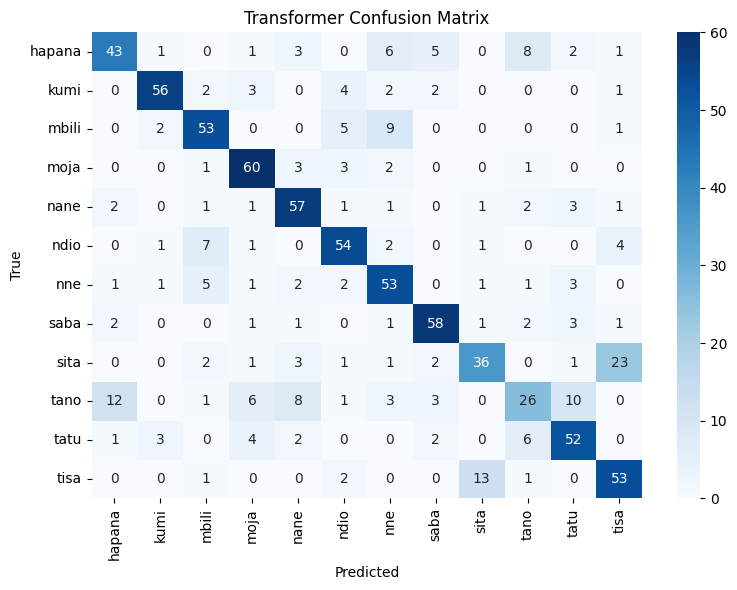

Saved files:
['lstm_learning_curves.png', 'lstm_confusion_matrix.png', 'lstm_misclassified_examples.csv', 'lstm_model.keras', 'transformer_model.keras', 'transformer_confusion_matrix.png', 'transformer_learning_curves.png', 'results_summary.txt']


In [24]:
#now resave the findings
save_dir = '/content/drive/MyDrive/david_lstm_baselines'
os.makedirs(save_dir, exist_ok=True)

# transformer learning curves (overwrites the broken-run version if one was saved)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(transformer_history.history['accuracy'], label='train accuracy')
plt.plot(transformer_history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Transformer Accuracy')

plt.subplot(1, 2, 2)
plt.plot(transformer_history.history['loss'], label='train loss')
plt.plot(transformer_history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Transformer Loss')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'transformer_learning_curves.png'), dpi=150)
plt.show()

# transformer confusion matrix (overwrites the broken-run version)
cm_transformer = confusion_matrix(y_val, transformer_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_transformer, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Transformer Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'transformer_confusion_matrix.png'), dpi=150)
plt.show()

# save the trained transformer model
transformer_model.save(os.path.join(save_dir, 'transformer_model.keras'))

# update the results summary with all 3 numbers
with open(os.path.join(save_dir, 'results_summary.txt'), 'w') as f:
    f.write("Model Results Summary\n")
    f.write("======================\n")
    f.write(f"Logistic Regression accuracy: {log_reg_acc:.4f}\n")
    f.write(f"Random Forest accuracy: {rf_acc:.4f}\n")
    f.write(f"LSTM accuracy: {lstm_acc:.4f}\n")
    f.write(f"Transformer accuracy: {transformer_acc:.4f}\n")

print("Saved files:")
print(os.listdir(save_dir))

In [25]:
MAX_DURATION_CNN = 3.0
TARGET_LEN_CNN = int(16000 * MAX_DURATION_CNN)

def preprocess_audio_2d(file_path):
    y, sr = librosa.load(file_path, sr=16000)
    if len(y) < TARGET_LEN_CNN:
        y = np.pad(y, (0, TARGET_LEN_CNN - len(y)))
    else:
        y = y[:TARGET_LEN_CNN]

    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    mel = librosa.feature.melspectrogram(y=y, sr=16000, n_fft=1024, hop_length=256, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return mel_norm.astype(np.float32)

X_cnn = []
for idx, row in train_df.iterrows():
    file_path = os.path.join(AUDIO_DIR, row['Word_id'])
    X_cnn.append(preprocess_audio_2d(file_path))
    if idx % 500 == 0:
        print(f"Processed {idx}/{len(train_df)}")

X_cnn = np.array(X_cnn)[..., np.newaxis]
print(X_cnn.shape)

X_cnn_train = X_cnn[train_idx]
X_cnn_val = X_cnn[val_idx]

Processed 0/4200
Processed 500/4200
Processed 1000/4200
Processed 1500/4200
Processed 2000/4200
Processed 2500/4200
Processed 3000/4200
Processed 3500/4200
Processed 4000/4200
(4200, 64, 188, 1)


In [26]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

def build_2d_cnn(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name="Swahili_2D_CNN")

cnn_model = build_2d_cnn(X_cnn_train.shape[1:], num_classes)
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

cnn_history = cnn_model.fit(
    X_cnn_train, y_train,
    validation_data=(X_cnn_val, y_val),
    epochs=30, batch_size=32,
    class_weight=class_weights,
    callbacks=cnn_callbacks, verbose=1
)

Model: "Swahili_2D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 188, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 188, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 188, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 94, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 94, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 47, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 23, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,628 (436.05 KB)

 Trainable params: 111,180 (434.30 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.0875 - loss: 2.6212 - val_accuracy: 0.0833 - val_loss: 2.5351 - learning_rate: 0.0010
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1307 - loss: 2.4679 - val_accuracy: 0.0833 - val_loss: 2.8012 - learning_rate: 0.0010
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1854 - loss: 2.2805 - val_accuracy: 0.0881 - val_loss: 4.0928 - learning_rate: 0.0010
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.2619 - loss: 2.0254 - val_accuracy: 0.0952 - val_loss: 4.9076 - learning_rate: 0.0010
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3771 - loss: 1.7365 - val_accuracy: 0.0833 - val_loss: 4.6332 - learning_rate: 5.0000e-04
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4601 - loss: 1.5520 - val_accuracy: 0.0988 - val_loss: 3.4580 - learning_rate: 5.0000e-04
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5116 -

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
CNN accuracy: 0.8761904761904762
              precision    recall  f1-score   support

      hapana       0.88      0.86      0.87        70
        kumi       0.78      0.90      0.83        70
       mbili       0.81      0.94      0.87        70
        moja       0.98      0.84      0.91        70
        nane       0.85      0.91      0.88        70
        ndio       0.98      0.83      0.90        70
         nne       0.80      0.90      0.85        70
        saba       0.93      0.89      0.91        70
        sita       0.95      0.89      0.92        70
        tano       0.84      0.80      0.82        70
        tatu       0.94      0.86      0.90        70
        tisa       0.85      0.90      0.88        70

    accuracy                           0.88       840
   macro avg       0.88      0.88      0.88       840
weighted avg       0.88      0.88      0.88       840



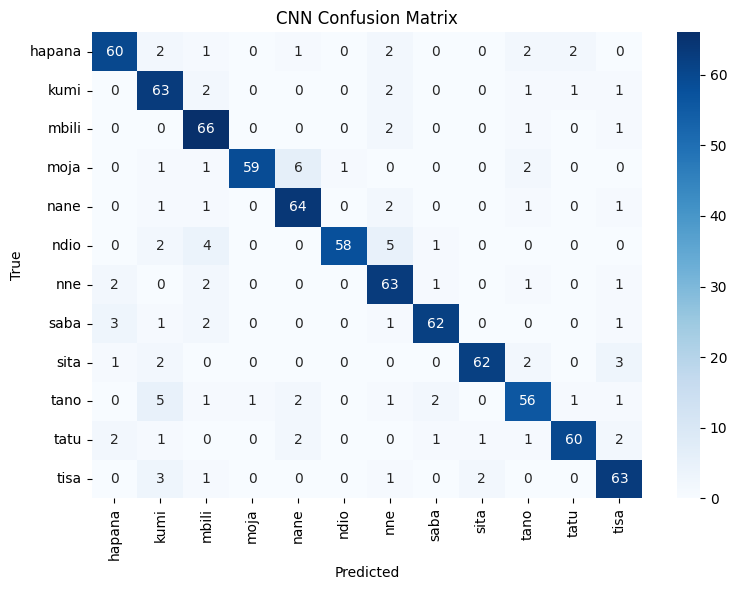

In [27]:
cnn_preds = np.argmax(cnn_model.predict(X_cnn_val), axis=1)
cnn_acc = accuracy_score(y_val, cnn_preds)
print("CNN accuracy:", cnn_acc)
print(classification_report(y_val, cnn_preds, target_names=le.classes_))

cm_cnn = confusion_matrix(y_val, cnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'cnn_confusion_matrix.png'), dpi=150)
plt.show()

In [ ]:
#save the results

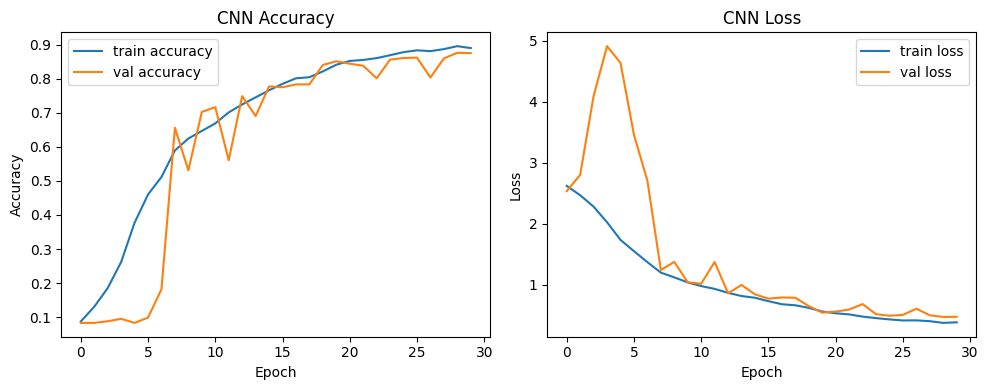

Saved files:
['lstm_learning_curves.png', 'lstm_confusion_matrix.png', 'lstm_misclassified_examples.csv', 'lstm_model.keras', 'transformer_model.keras', 'transformer_confusion_matrix.png', 'transformer_learning_curves.png', 'results_summary.txt', 'cnn_confusion_matrix.png', 'cnn_learning_curves.png', 'cnn_model.keras']


In [28]:
# CNN learning curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='train accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Accuracy')

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='train loss')
plt.plot(cnn_history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Loss')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'cnn_learning_curves.png'), dpi=150)
plt.show()

# save the trained CNN model
cnn_model.save(os.path.join(save_dir, 'cnn_model.keras'))

# update the results summary with all 5 numbers
with open(os.path.join(save_dir, 'results_summary.txt'), 'w') as f:
    f.write("Model Results Summary\n")
    f.write("======================\n")
    f.write(f"Logistic Regression accuracy: {log_reg_acc:.4f}\n")
    f.write(f"Random Forest accuracy: {rf_acc:.4f}\n")
    f.write(f"LSTM accuracy: {lstm_acc:.4f}\n")
    f.write(f"Transformer accuracy: {transformer_acc:.4f}\n")
    f.write(f"CNN accuracy: {cnn_acc:.4f}\n")

print("Saved files:")
print(os.listdir(save_dir))